In [1]:
%load_ext autoreload
%autoreload 2
 
from prism.config import PROCESSED_DATA_DIR, MODELS_DIR
from prism.PRiSM_functions import (
    normalise, 
    train_mlp_batched, 
    modelStats, 
    extract_weights, 
    partialResponses, 
    prPlots
)
from prism.prlasso import prLASSO
from prism.prnomogram import prnomogram_refactor
from prism.maskedmlp import (
    mlpmask_pytorch, 
    generate_mask, 
    get_model_weights_with_biases
)
from prism.save_models import (
    save_mlp,
    save_lasso,
    save_prn
)

import pandas as pd
import numpy as np
import torch
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

2024-07-05 13:50:07.214 | INFO     | prism.config:<module>:11 - PROJ_ROOT path is: C:\Users\Henry Pigot\Documents\MEGAsync\2024 post doc\explainable survival prediction model\prism_github


## Parameters

In [2]:
device = 'cpu'
method = 'dirac'
SAVE_MODELS = False

seed = 257

np.random.seed(seed)
torch.manual_seed(seed)

In [3]:
# Print gpu hardware info
if torch.cuda.is_available():
    print("Number of CUDA devices:", torch.cuda.device_count())
    
    for i in range(torch.cuda.device_count()):
        print("CUDA Device #{}: {}".format(i, torch.cuda.get_device_name(i)))
    
    for i in range(torch.cuda.device_count()):
        print("Total memory of CUDA Device #{}: {:.2f} GB".format(
            i, torch.cuda.get_device_properties(i).total_memory / 1e9))
    
    for i in range(torch.cuda.device_count()):
        device_properties = torch.cuda.get_device_properties(i)
        print("CUDA Capability of Device #{}: {}.{}".format(
            i, device_properties.major, device_properties.minor))
    
    print("Default data type for CUDA tensors:", torch.get_default_dtype())
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("CUDA is not available.")


CUDA is not available.


## Import data

Preprocessed and split into train, test, and validate.

Target: `oneyearmort`

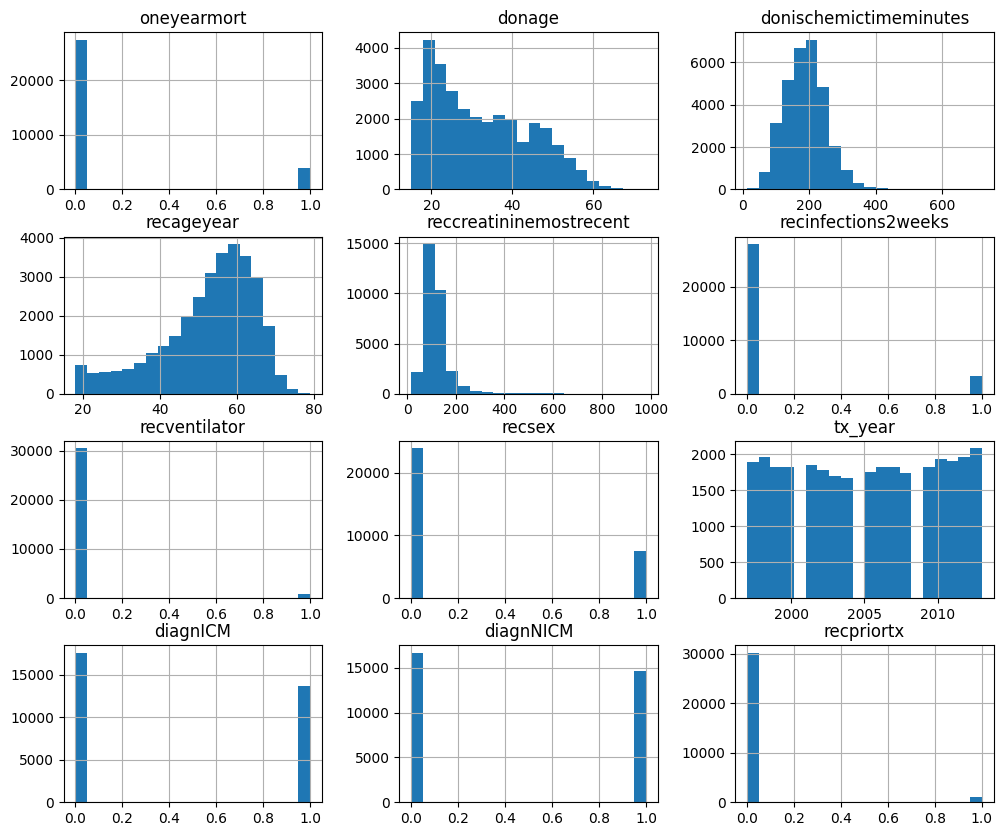

In [4]:
data_train = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_train.csv'))
data_test = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_test.csv'))
data_val = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_val.csv'))

data_train_test = pd.concat([data_train,data_test]) # used for axis annotation in some plotting functions

# drop id column
data_train.drop('trr_id_code',axis=1,inplace=True)
data_test.drop('trr_id_code',axis=1,inplace=True)
data_val.drop('trr_id_code',axis=1,inplace=True)

target_col = 'oneyearmort'

data_train.hist(bins=20,figsize=(12,10));

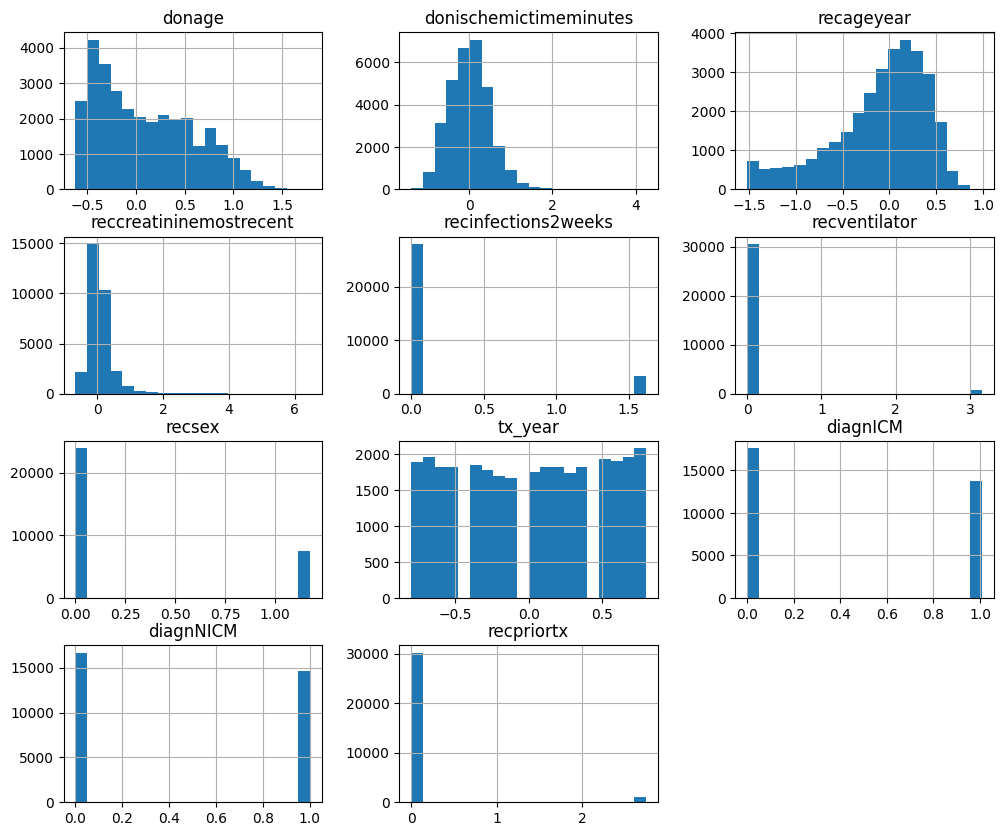

In [5]:
x_train0 = data_train.drop(target_col,axis=1)
y_train = data_train[target_col]

x_test0 = data_test.drop(target_col,axis=1)
y_test = data_test[target_col]

x_val0 = data_val.drop(target_col,axis=1)
y_val = data_val[target_col]

[x_train,x_test] = normalise(x_train0,x_test0)
x_val = normalise(x_val0)

# check result
x_train.hist(bins=20,figsize=(12,10));

## Train MLP

In [6]:
mlp_params = {
    'n_hidden': 10,
    'weight_decay': 1e-5,
    'lr': 0.001,
    'patience': 50,
    'tolerance': 0.0001,
    'batch_size': 1024,
    'device': device,
    'seed': seed
}

mlp_batched = train_mlp_batched(x_train, y_train, x_test, y_test, **mlp_params)

Epoch 0: Train loss 0.6690, Val loss 0.6166
Epoch 1: Train loss 0.5749, Val loss 0.5303
Epoch 2: Train loss 0.5062, Val loss 0.4680
Epoch 3: Train loss 0.4573, Val loss 0.4224
Epoch 4: Train loss 0.4240, Val loss 0.3906
Epoch 5: Train loss 0.4014, Val loss 0.3693
Epoch 6: Train loss 0.3869, Val loss 0.3563
Epoch 7: Train loss 0.3782, Val loss 0.3485
Epoch 8: Train loss 0.3726, Val loss 0.3440
Epoch 9: Train loss 0.3694, Val loss 0.3416
Epoch 10: Train loss 0.3667, Val loss 0.3402
Epoch 11: Train loss 0.3653, Val loss 0.3395
Epoch 12: Train loss 0.3644, Val loss 0.3393
Epoch 13: Train loss 0.3640, Val loss 0.3392
Epoch 14: Train loss 0.3631, Val loss 0.3391
Epoch 15: Train loss 0.3621, Val loss 0.3391
Epoch 16: Train loss 0.3624, Val loss 0.3392
Epoch 17: Train loss 0.3617, Val loss 0.3392
Epoch 18: Train loss 0.3613, Val loss 0.3393
Epoch 19: Train loss 0.3611, Val loss 0.3392
Epoch 20: Train loss 0.3611, Val loss 0.3393
Epoch 21: Train loss 0.3608, Val loss 0.3394
Epoch 22: Train loss

## Evaluate MLP

In [7]:
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32,device=device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32,device=device)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

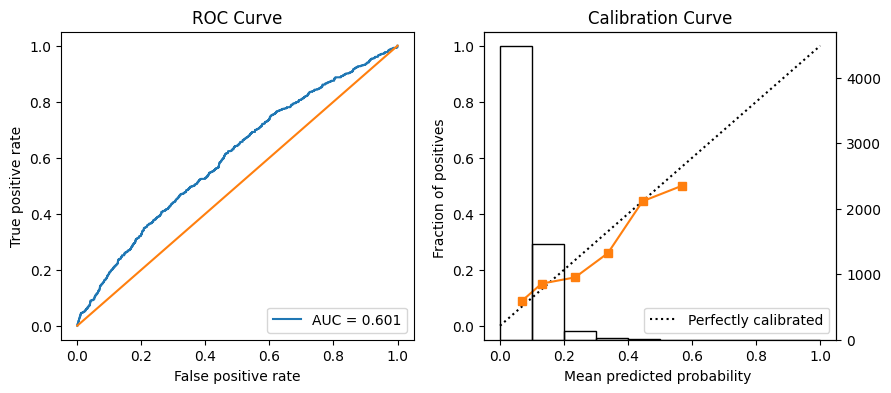


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.241
specificity: 0.864
accuracy: 0.797
ppv: 0.175
auc score: 0.601
auc lower ci: 0.577
auc upper ci: 0.626
-------------------------


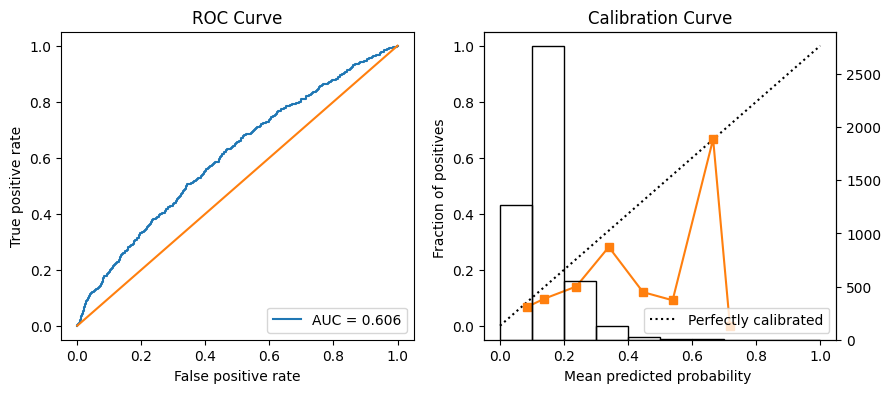


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.667
specificity: 0.489
accuracy: 0.507
ppv: 0.126
auc score: 0.606
auc lower ci: 0.581
auc upper ci: 0.636
-------------------------


{'prevalence': 0.123,
 'sensitivity': 0.667,
 'specificity': 0.489,
 'accuracy': 0.507,
 'ppv': 0.126,
 'auc score': 0.606,
 'auc lower ci': '0.581',
 'auc upper ci': '0.636'}

In [8]:
# Get model inference
mlp_batched.eval()
with torch.no_grad():
    y_test_blackbox = mlp_batched(x_test_tensor).to('cpu').numpy()
    y_val_blackbox = mlp_batched(x_val_tensor).to('cpu').numpy()

mlp_metrics_test = modelStats(y_test_blackbox, y_test, y_train, ROC=True, mdlCalibration=True, metricNames=True, auc_ci=True)
modelStats(y_val_blackbox, y_val, y_train, ROC=True, mdlCalibration=True, metricNames=True, auc_ci=True)

## Save MLP

In [9]:
if SAVE_MODELS:
    save_mlp(mlp_batched, mlp_params, mlp_metrics_test, MODELS_DIR)

MLP model saved as mlp_model_20240705_135534


## MLP LASSO

In [10]:
blackbox_weights = extract_weights(mlp_batched)

F_covariates_train, F_covariates_test, bivariate_inputs = partialResponses(x_train, x_test, blackbox_weights, method=method,device=device)

Univariate Responses:
Column 0:
Column 1:
Column 2:
Column 3:
Column 4:
Column 5:
Column 6:
Column 7:
Column 8:
Column 9:
Column 10:
Bivariate Responses:
Columns 0 & 1:
Columns 0 & 2:
Columns 0 & 3:
Columns 0 & 4:
Columns 0 & 5:
Columns 0 & 6:
Columns 0 & 7:
Columns 0 & 8:
Columns 0 & 9:
Columns 0 & 10:
Columns 1 & 2:
Columns 1 & 3:
Columns 1 & 4:
Columns 1 & 5:
Columns 1 & 6:
Columns 1 & 7:
Columns 1 & 8:
Columns 1 & 9:
Columns 1 & 10:
Columns 2 & 3:
Columns 2 & 4:
Columns 2 & 5:
Columns 2 & 6:
Columns 2 & 7:
Columns 2 & 8:
Columns 2 & 9:
Columns 2 & 10:
Columns 3 & 4:
Columns 3 & 5:
Columns 3 & 6:
Columns 3 & 7:
Columns 3 & 8:
Columns 3 & 9:
Columns 3 & 10:
Columns 4 & 5:
Columns 4 & 6:
Columns 4 & 7:
Columns 4 & 8:
Columns 4 & 9:
Columns 4 & 10:
Columns 5 & 6:
Columns 5 & 7:
Columns 5 & 8:
Columns 5 & 9:
Columns 5 & 10:
Columns 6 & 7:
Columns 6 & 8:
Columns 6 & 9:
Columns 6 & 10:
Columns 7 & 8:
Columns 7 & 9:
Columns 7 & 10:
Columns 8 & 9:
Columns 8 & 10:
Columns 9 & 10:
Residual


Plot all univariate partial responses, for initial eval of MLP training results.

In [11]:
betas_univariate = np.zeros([F_covariates_train.shape[1],1])
betas_univariate[:x_train.shape[1],0] = 1

0 - univ


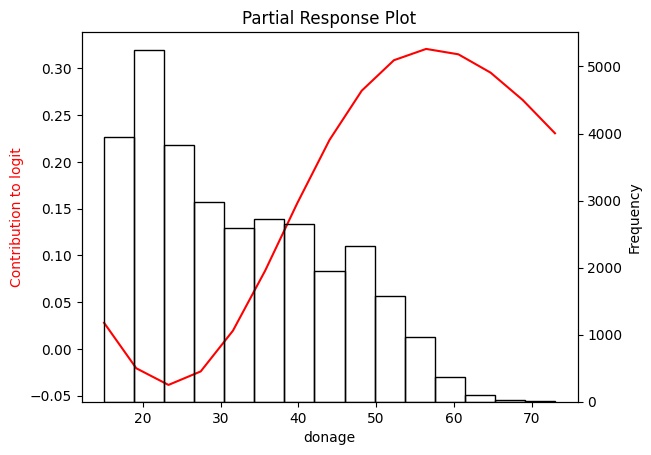

1 - univ


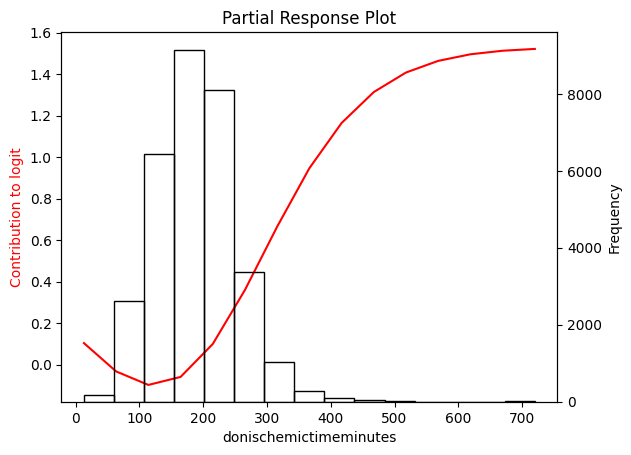

2 - univ


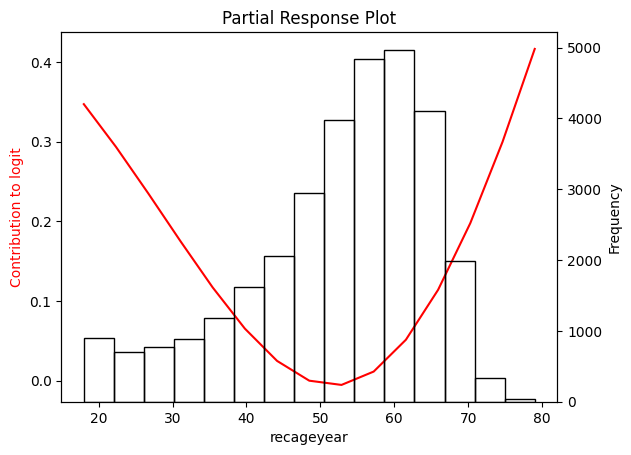

3 - univ


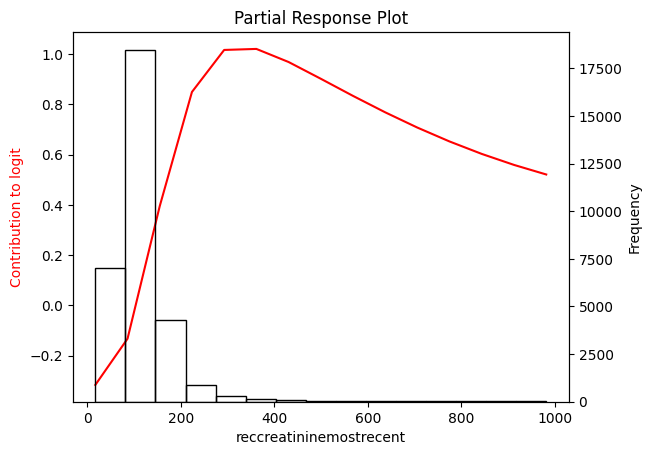

4 - univ


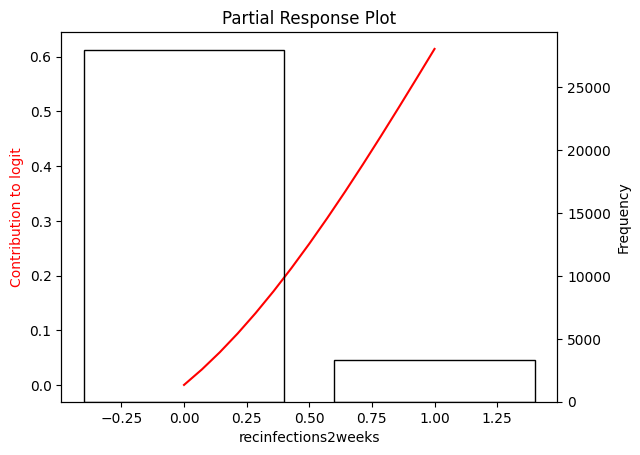

5 - univ


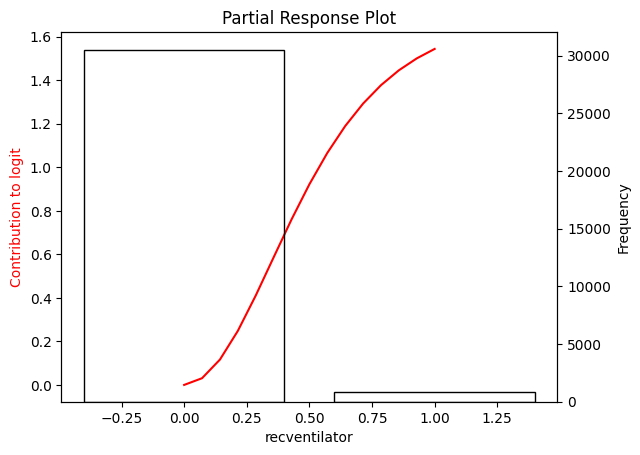

6 - univ


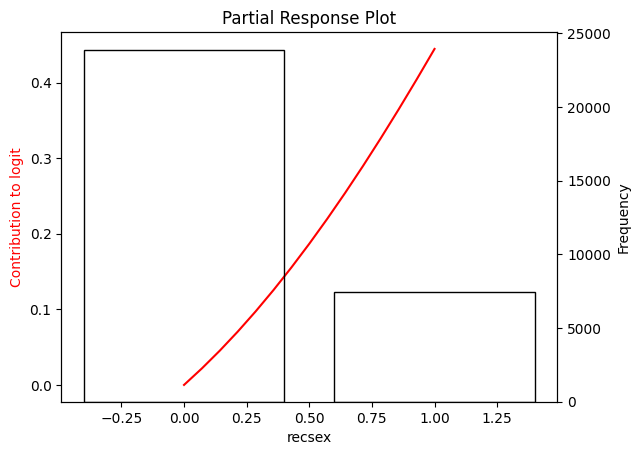

7 - univ


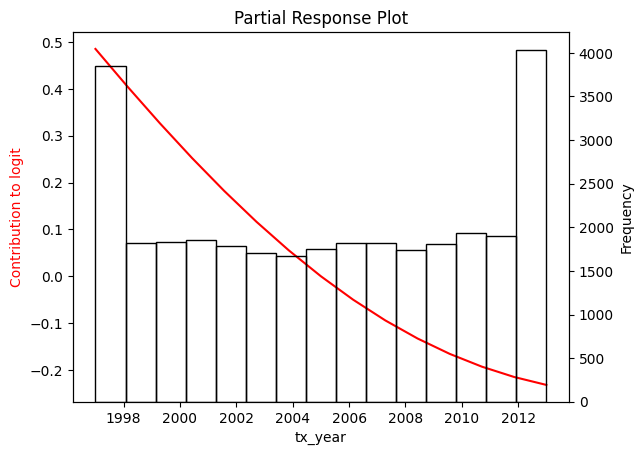

8 - univ


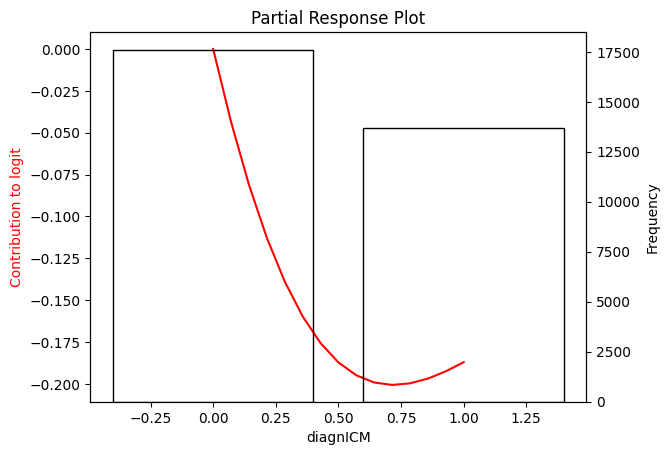

9 - univ


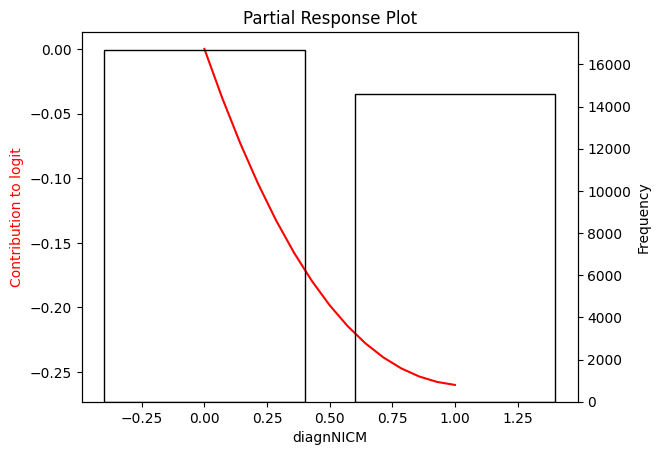

10 - univ


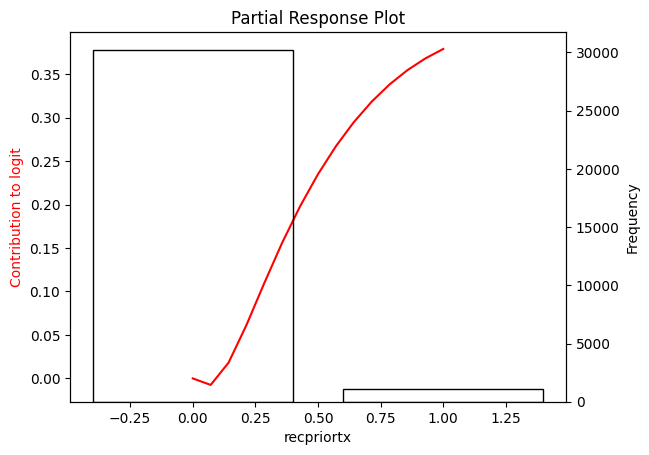

In [12]:
prPlots(betas_univariate, 0, x_train0, x_train, data_train_test, blackbox_weights, bivariate_inputs, n_steps = 15, sd_scale=2, method=method, device=device)

## Run LASSO on MLP Partial Responses

**Note** losses shown are normalized to loss at epoch 0, so not for comparing between hyperparameter sets.

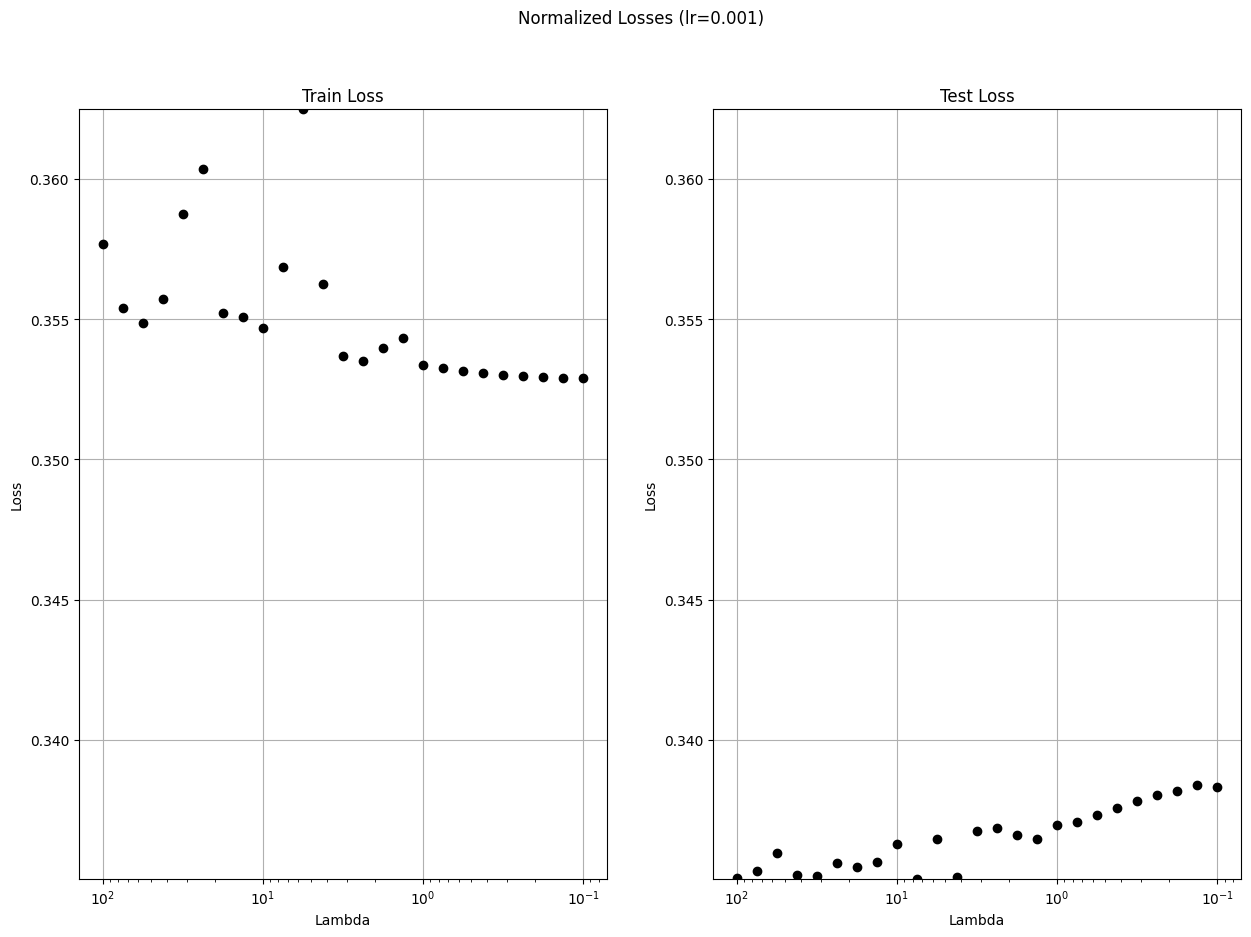

23 - Lambda 0.13335: Test AUC 0.5976, n_univ: 10, n_biv: 46
 0 - Lambda 100.00000: Train AUC 0.6179, Train Deviance 22702.7540, Test AUC 0.5778, Test Deviance 4118.1219, n_univ: 4, n_biv: 0
    -> Within 1 SD of maximum Test AUC
 1 - Lambda 74.98942: Train AUC 0.6322, Train Deviance 22568.0476, Test AUC 0.5881, Test Deviance 4107.8366, n_univ: 6, n_biv: 0
 2 - Lambda 56.23413: Train AUC 0.6395, Train Deviance 22468.4754, Test AUC 0.5943, Test Deviance 4102.2627, n_univ: 6, n_biv: 0
 3 - Lambda 42.16965: Train AUC 0.6433, Train Deviance 22402.3386, Test AUC 0.5968, Test Deviance 4101.2217, n_univ: 7, n_biv: 0
 4 - Lambda 31.62278: Train AUC 0.6461, Train Deviance 22350.5526, Test AUC 0.5994, Test Deviance 4100.7713, n_univ: 8, n_biv: 0
    -> Minimum Test Deviance at this lambda
 5 - Lambda 23.71374: Train AUC 0.6481, Train Deviance 22312.3397, Test AUC 0.6006, Test Deviance 4101.4939, n_univ: 8, n_biv: 1
 6 - Lambda 17.78279: Train AUC 0.6500, Train Deviance 22279.3315, Test AUC 0.6014

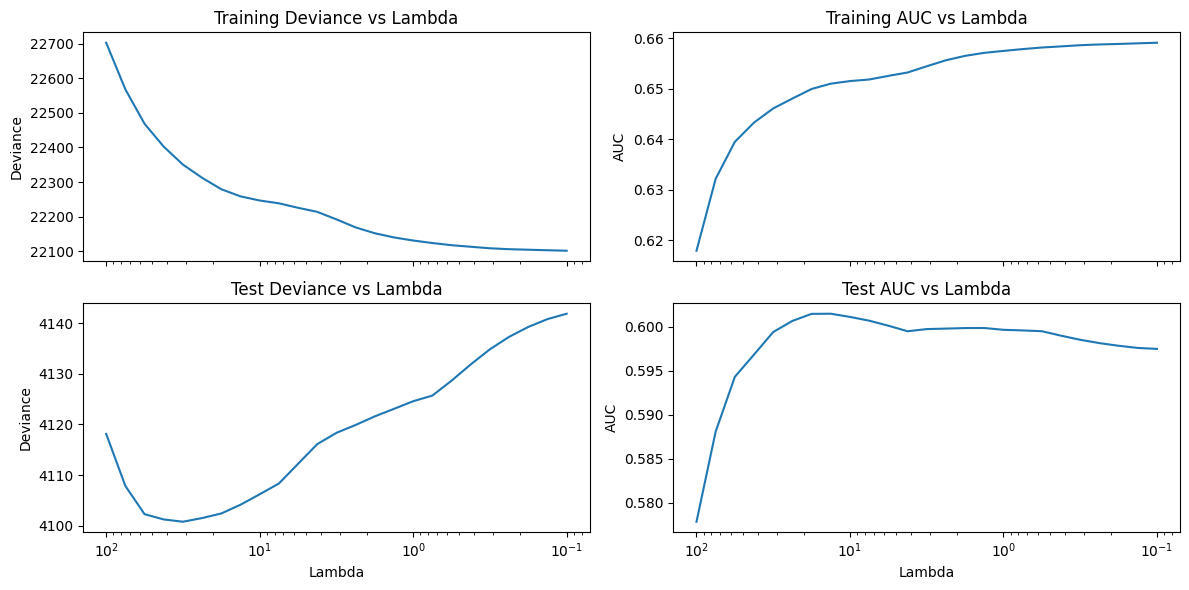

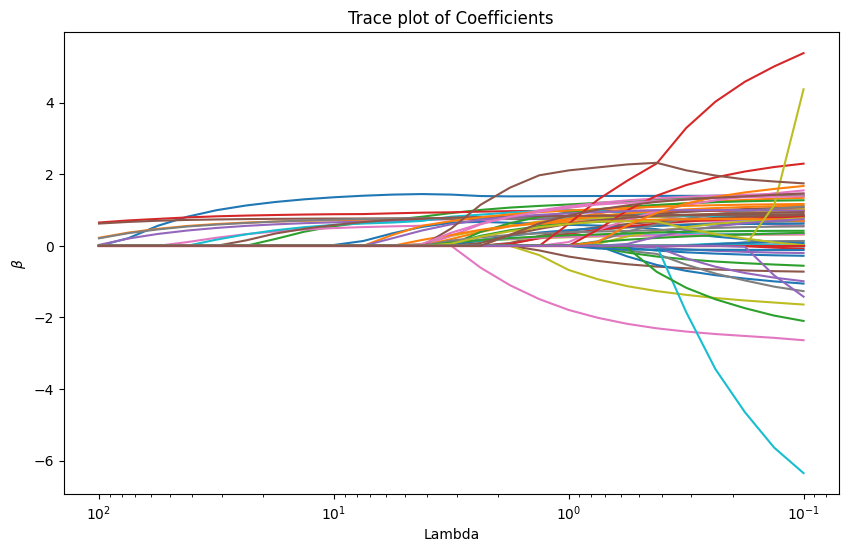

In [13]:
num_lambdas = 25
verbose = True
lambdas, betas, trainAUC, testAUC, trainDev, testDev, glmPred = prLASSO(F_covariates_train, F_covariates_test, y_train, y_test, num_lambdas=num_lambdas, log_min_lambda=-1, verbose=verbose)

In [14]:
# userLambda = selectLambda(lambdas, betas, testAUC, testDev, x_train,bivariate_inputs)
userLambda = 7
lambdas[userLambda]

13.33521432163324

## Plots of the MLP partial responses for the selected lambda

0 - univ


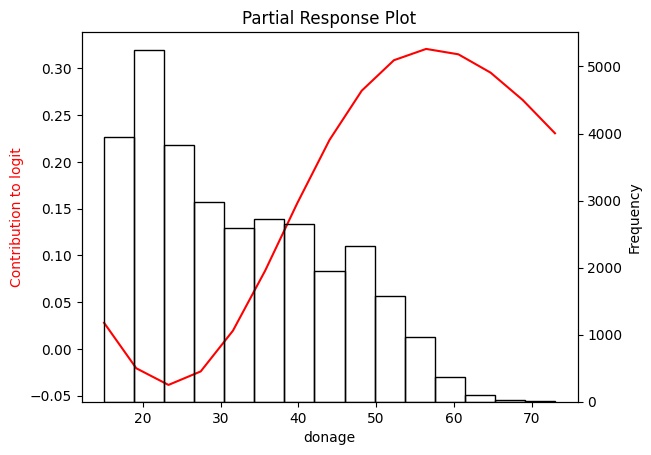

1 - univ


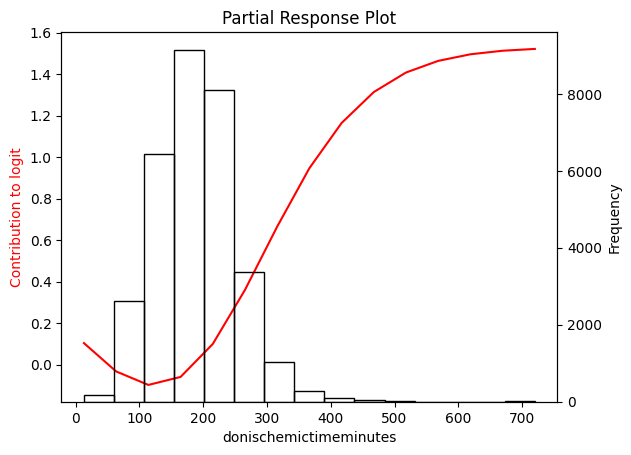

2 - univ


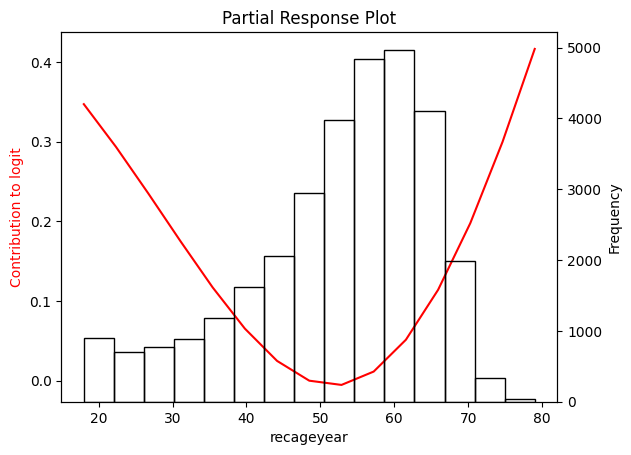

3 - univ


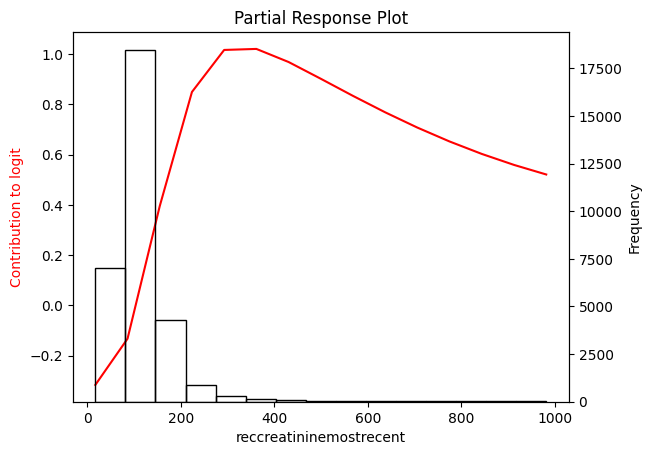

4 - univ


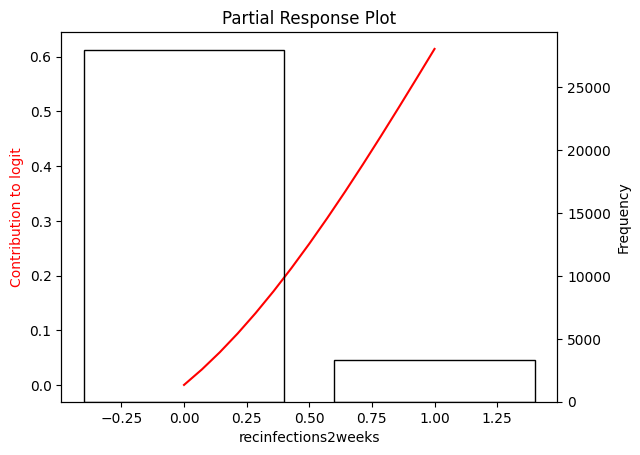

5 - univ


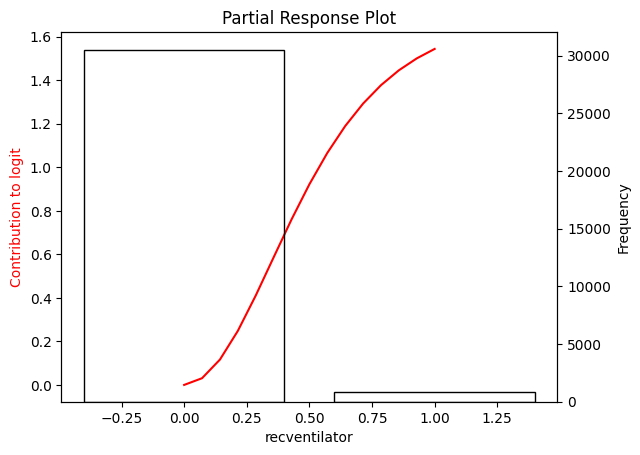

6 - univ


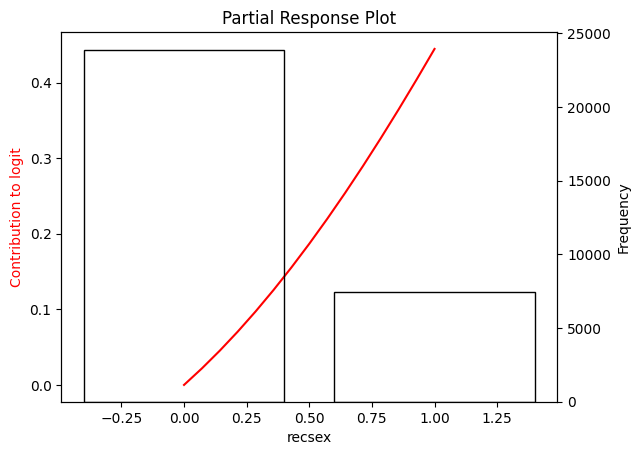

7 - univ


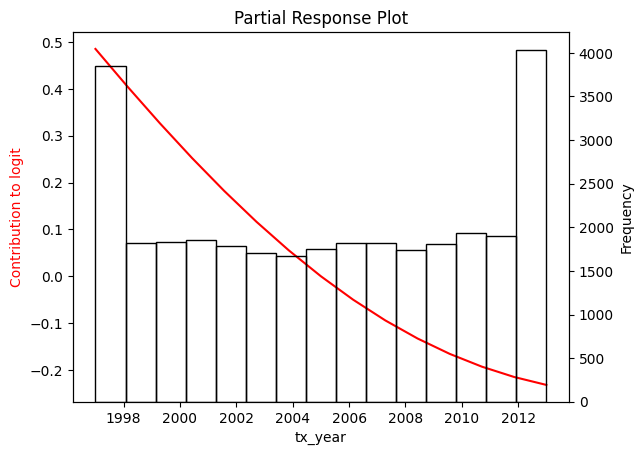

9 - univ


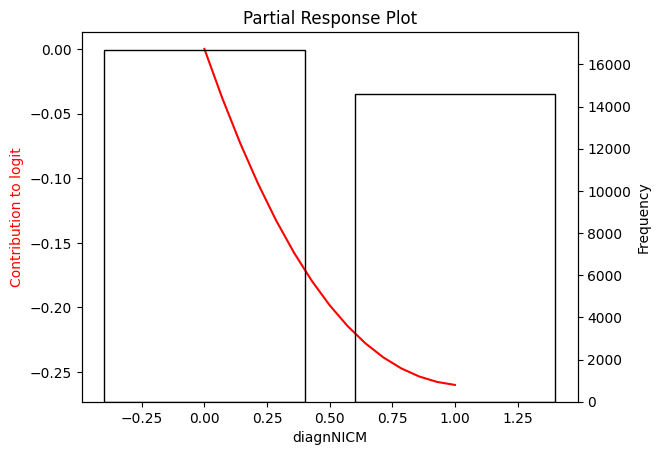

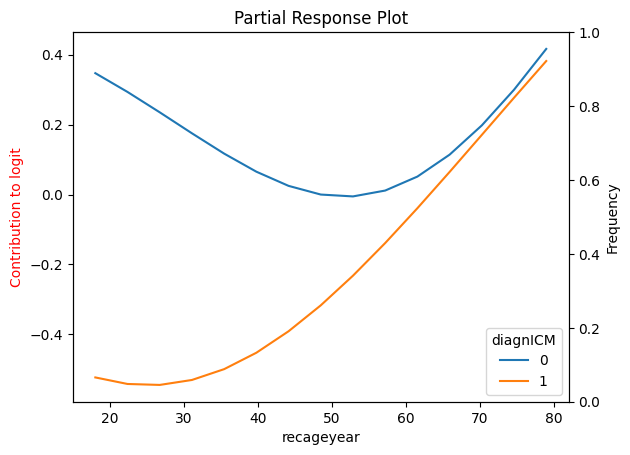

In [15]:
prPlots(betas, userLambda, x_train0, x_train, data_train_test, blackbox_weights, bivariate_inputs, n_steps = 15, sd_scale=2, method=method, device=device)

## Train the Partial Response Network using the responses from the selected lambda

['donage', 'donischemictimeminutes', 'recageyear', 'reccreatininemostrecent', 'recinfections2weeks', 'recventilator', 'recsex', 'tx_year', 'diagnNICM', 'recageyear : diagnICM']


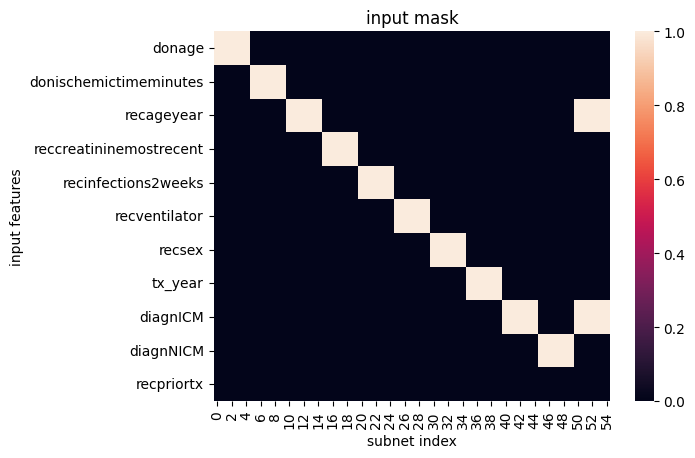

In [16]:
mask, nPr = generate_mask(betas, userLambda, x_train, bivariate_inputs,include_bivariate_as_univariate=True)

Note, that changing the patience from 10 to 100 caused the predicted probability histogram to more closely match previous iterations. However, inference seemed unusually slow.

After experimenting with hyperparameters, I changed from the default initialization (Kaiming, suitable for relu), to specifically Xavier (Glorot) with gains set according to the activation functions of each layer.

With this and the "default" params, training stopped after 227 (rather than 300) epochs.

In [18]:
prn_params = {
    'n_hidden': nPr,
    'mask': mask,
    'subnet_nodes': 5,
    'iter': 10000,
    'lr': 0.05,
    'weight_decay': 0.00001,
    'tolerance': 0.0001,
    'patience': 100,
    'device': device,
    'seed': seed
}

prn = mlpmask_pytorch(x_train, y_train, x_test, y_test, **prn_params)

Epoch 0, Training loss 0.7491949796676636, Validation loss 0.5058018565177917
Epoch 1, Training loss 0.5208706855773926, Validation loss 0.3845042586326599
Epoch 2, Training loss 0.4087001085281372, Validation loss 0.34338873624801636
Epoch 3, Training loss 0.3777748942375183, Validation loss 0.3566133677959442
Epoch 4, Training loss 0.3964877128601074, Validation loss 0.38072434067726135
Epoch 5, Training loss 0.42082342505455017, Validation loss 0.39131689071655273
Epoch 6, Training loss 0.4279251992702484, Validation loss 0.38494932651519775
Epoch 7, Training loss 0.41638851165771484, Validation loss 0.36732038855552673
Epoch 8, Training loss 0.39412549138069153, Validation loss 0.34791669249534607
Epoch 9, Training loss 0.3729674220085144, Validation loss 0.33749744296073914
Epoch 10, Training loss 0.3656228184700012, Validation loss 0.34155094623565674
Epoch 11, Training loss 0.37698012590408325, Validation loss 0.3493284285068512
Epoch 12, Training loss 0.39084920287132263, Valid

## Evaluate the Partial Response Network

In [19]:
# Get model inference
y_test_prn_pytorch = prn.predict(x_test_tensor, device=device).to('cpu').numpy()
y_val_prn_pytorch = prn.predict(x_val_tensor, device=device).to('cpu').numpy()

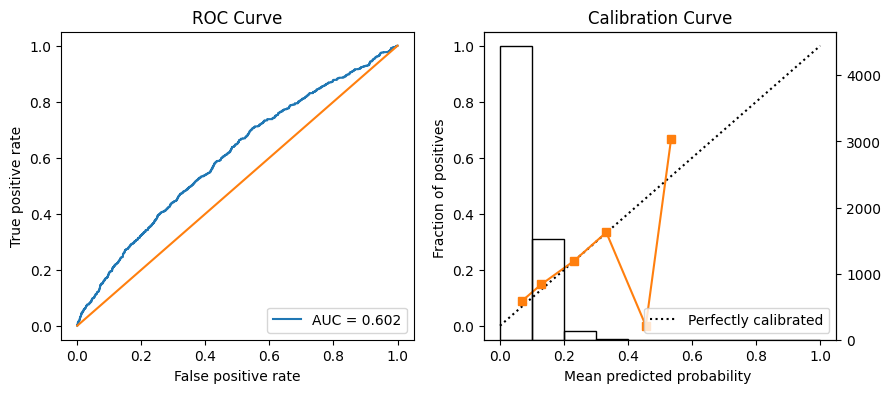


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.235
specificity: 0.867
accuracy: 0.799
ppv: 0.174
auc score: 0.602
auc lower ci: 0.578
auc upper ci: 0.63
-------------------------


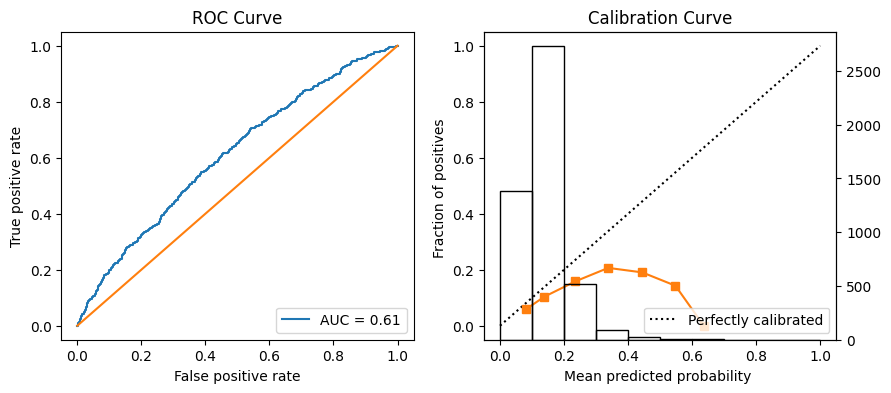


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.639
specificity: 0.512
accuracy: 0.524
ppv: 0.126
auc score: 0.61
auc lower ci: 0.585
auc upper ci: 0.636
-------------------------


{'prevalence': 0.123,
 'sensitivity': 0.639,
 'specificity': 0.512,
 'accuracy': 0.524,
 'ppv': 0.126,
 'auc score': 0.61,
 'auc lower ci': '0.585',
 'auc upper ci': '0.636'}

In [20]:
prn_metrics_test = modelStats(y_test_prn_pytorch, y_test, y_train, auc_ci=True)
modelStats(y_val_prn_pytorch,y_val,y_train, auc_ci=True)

In [21]:
if SAVE_MODELS:
    save_prn(prn, prn_params, prn_metrics_test, MODELS_DIR)

PRN model saved as prn_model_20240705_140928


Quick prPlots check of all univariate features using , before proceeding with LASSO on the Partial Response Network.

0 - univ


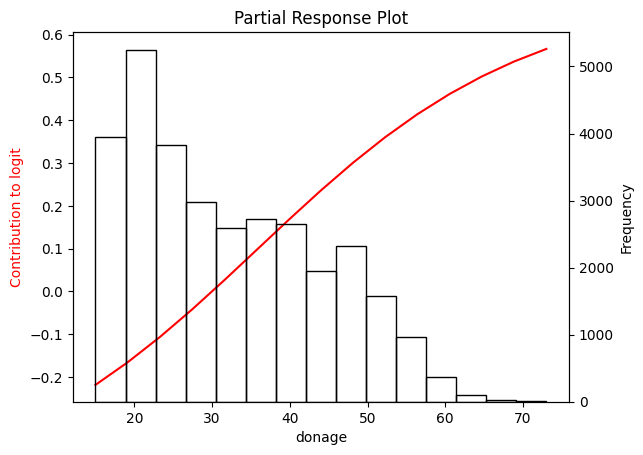

1 - univ


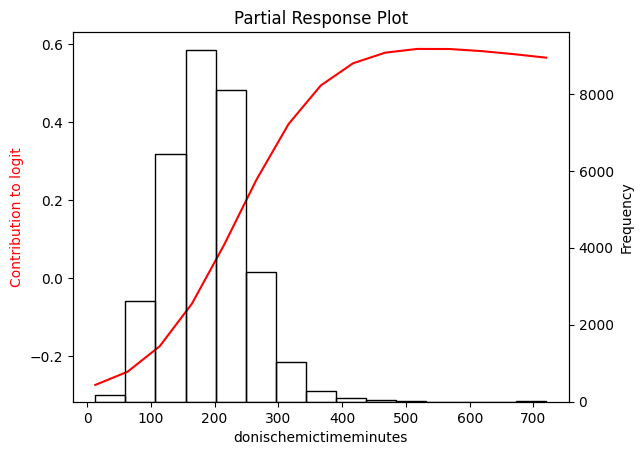

2 - univ


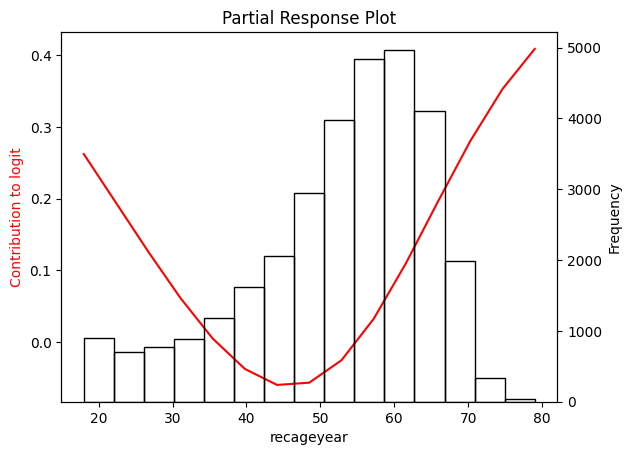

3 - univ


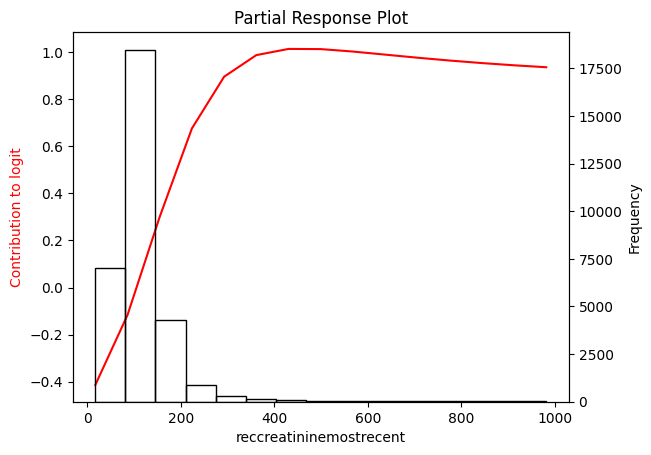

4 - univ


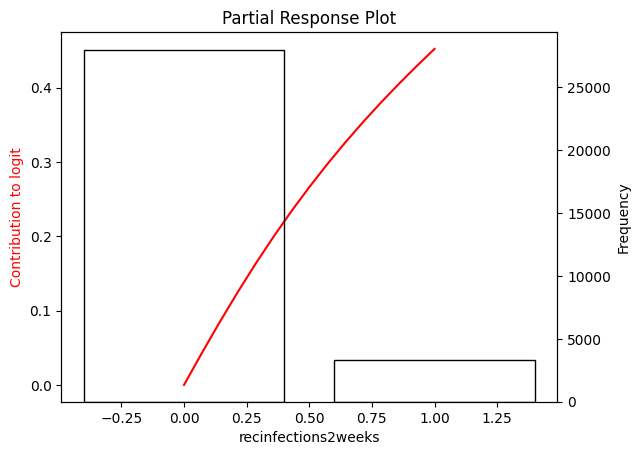

5 - univ


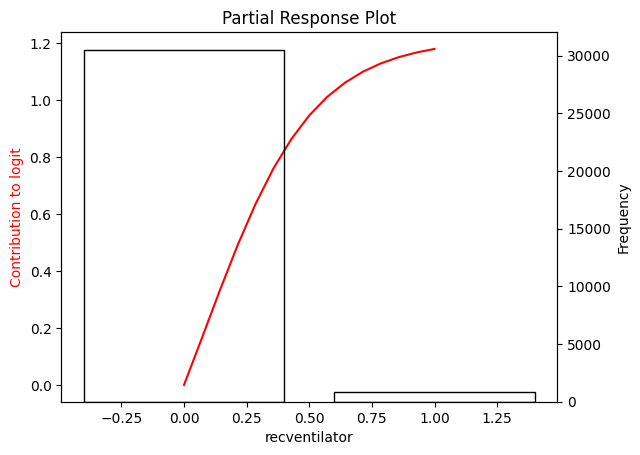

6 - univ


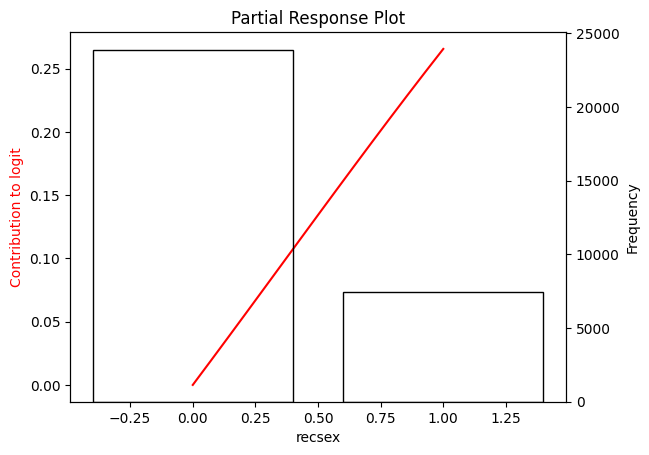

7 - univ


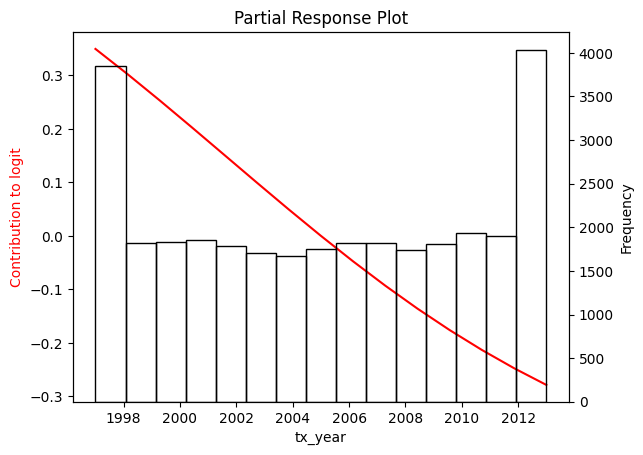

8 - univ


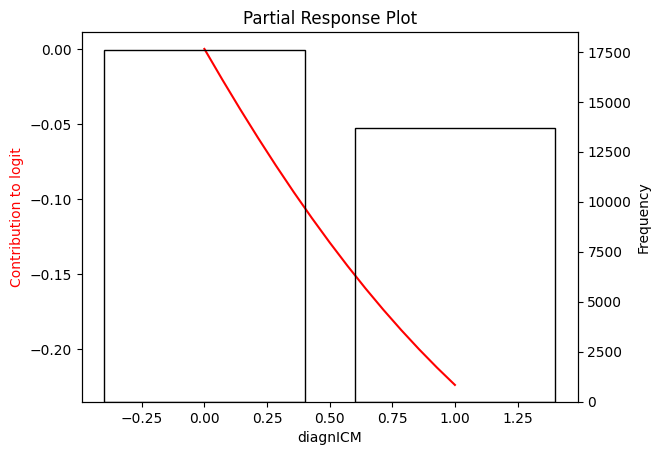

9 - univ


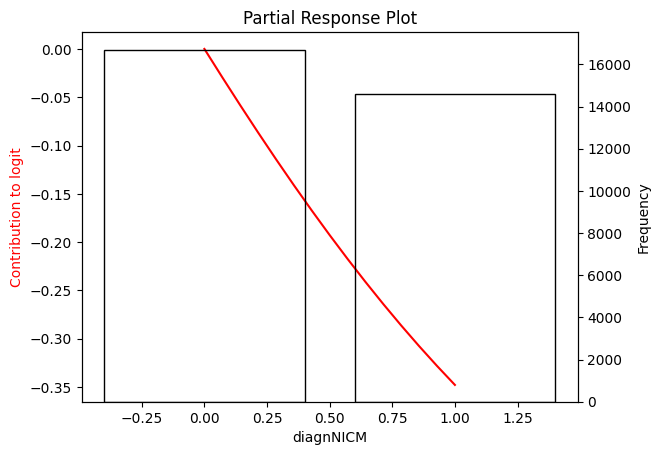

10 - univ


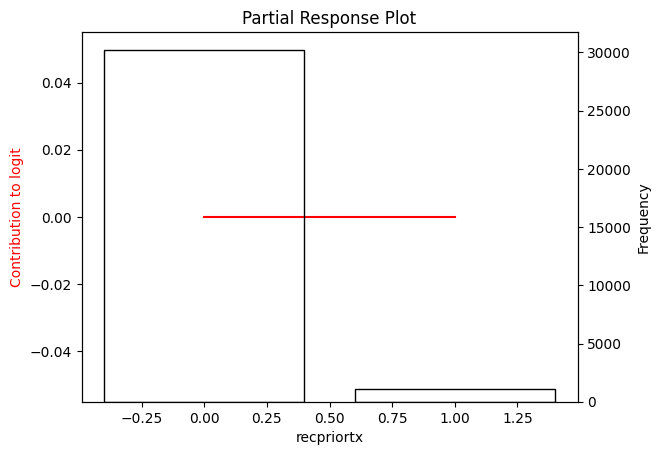

In [22]:
prPlots(betas_univariate, 0, x_train0, x_train, data_train_test, prn, bivariate_inputs, n_steps = 15, sd_scale=2, method=method,device=device)

## LASSO on the Partial Response Network

In [23]:
prn_weights = get_model_weights_with_biases(prn)

F_covariates_train_prn, F_covariates_test_prn, bivariate_inputs_prn = partialResponses(x_train, x_test, prn_weights, residual=False, method = method,device=device);

Univariate Responses:
Column 0:
Column 1:
Column 2:
Column 3:
Column 4:
Column 5:
Column 6:
Column 7:
Column 8:
Column 9:
Column 10:
Bivariate Responses:
Columns 0 & 1:
Columns 0 & 2:
Columns 0 & 3:
Columns 0 & 4:
Columns 0 & 5:
Columns 0 & 6:
Columns 0 & 7:
Columns 0 & 8:
Columns 0 & 9:
Columns 0 & 10:
Columns 1 & 2:
Columns 1 & 3:
Columns 1 & 4:
Columns 1 & 5:
Columns 1 & 6:
Columns 1 & 7:
Columns 1 & 8:
Columns 1 & 9:
Columns 1 & 10:
Columns 2 & 3:
Columns 2 & 4:
Columns 2 & 5:
Columns 2 & 6:
Columns 2 & 7:
Columns 2 & 8:
Columns 2 & 9:
Columns 2 & 10:
Columns 3 & 4:
Columns 3 & 5:
Columns 3 & 6:
Columns 3 & 7:
Columns 3 & 8:
Columns 3 & 9:
Columns 3 & 10:
Columns 4 & 5:
Columns 4 & 6:
Columns 4 & 7:
Columns 4 & 8:
Columns 4 & 9:
Columns 4 & 10:
Columns 5 & 6:
Columns 5 & 7:
Columns 5 & 8:
Columns 5 & 9:
Columns 5 & 10:
Columns 6 & 7:
Columns 6 & 8:
Columns 6 & 9:
Columns 6 & 10:
Columns 7 & 8:
Columns 7 & 9:
Columns 7 & 10:
Columns 8 & 9:
Columns 8 & 10:
Columns 9 & 10:
Residual


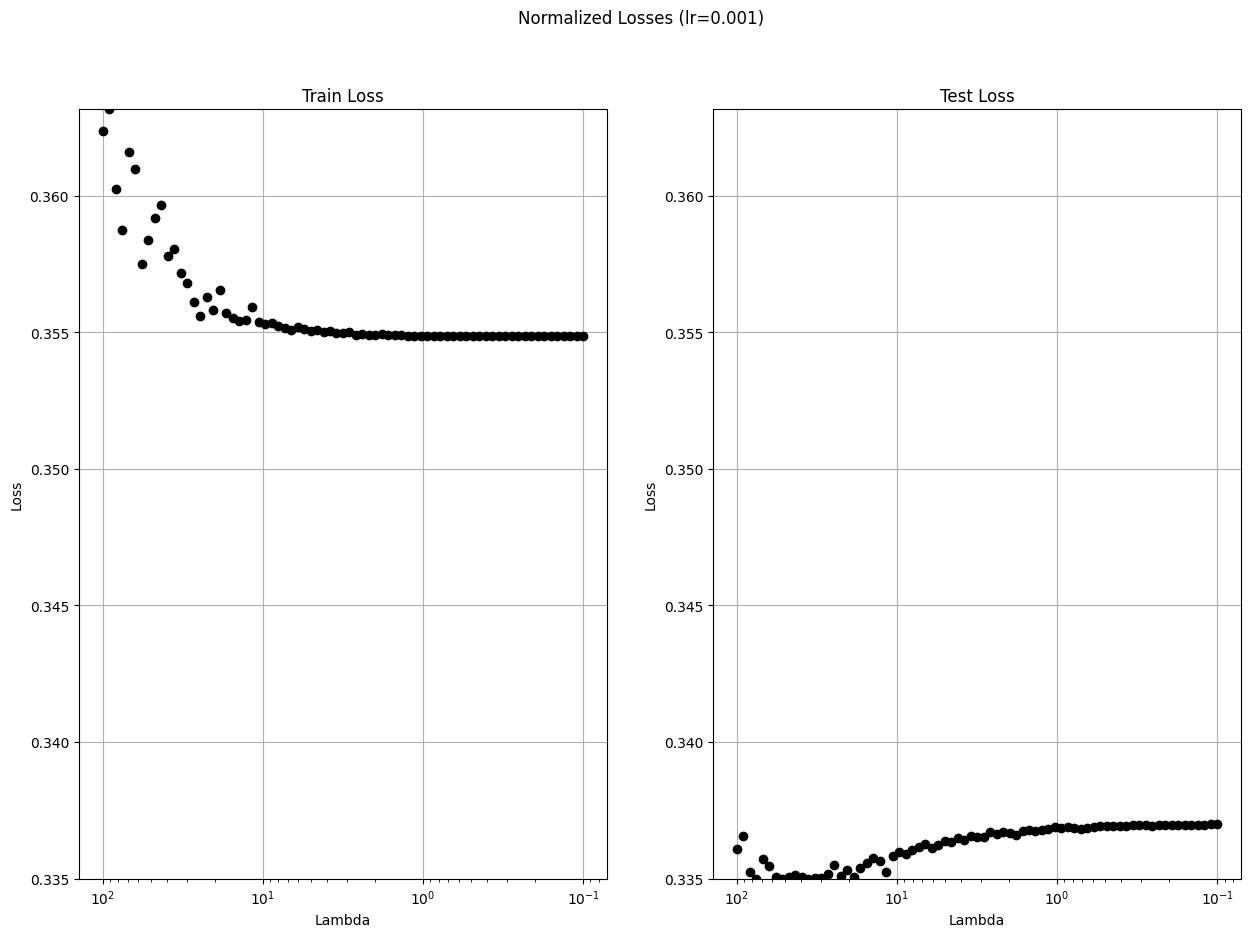

73 - Lambda 0.10978: Test AUC 0.6018, n_univ: 10, n_biv: 1
 0 - Lambda 100.00000: Train AUC 0.6168, Train Deviance 22745.3330, Test AUC 0.5818, Test Deviance 4119.2754, n_univ: 4, n_biv: 0
    -> Within 1 SD of maximum Test AUC
 1 - Lambda 91.08764: Train AUC 0.6228, Train Deviance 22694.6960, Test AUC 0.5853, Test Deviance 4113.8151, n_univ: 4, n_biv: 0
 2 - Lambda 82.96959: Train AUC 0.6276, Train Deviance 22647.3210, Test AUC 0.5883, Test Deviance 4109.3436, n_univ: 5, n_biv: 0
    -> Within 1 SD of minimum Test Deviance
 3 - Lambda 75.57504: Train AUC 0.6309, Train Deviance 22606.9829, Test AUC 0.5903, Test Deviance 4106.2062, n_univ: 5, n_biv: 0
 4 - Lambda 68.83952: Train AUC 0.6346, Train Deviance 22562.6724, Test AUC 0.5929, Test Deviance 4103.4870, n_univ: 5, n_biv: 0
 5 - Lambda 62.70430: Train AUC 0.6371, Train Deviance 22526.1738, Test AUC 0.5944, Test Deviance 4101.8651, n_univ: 6, n_biv: 0
 6 - Lambda 57.11586: Train AUC 0.6387, Train Deviance 22495.9789, Test AUC 0.5954,

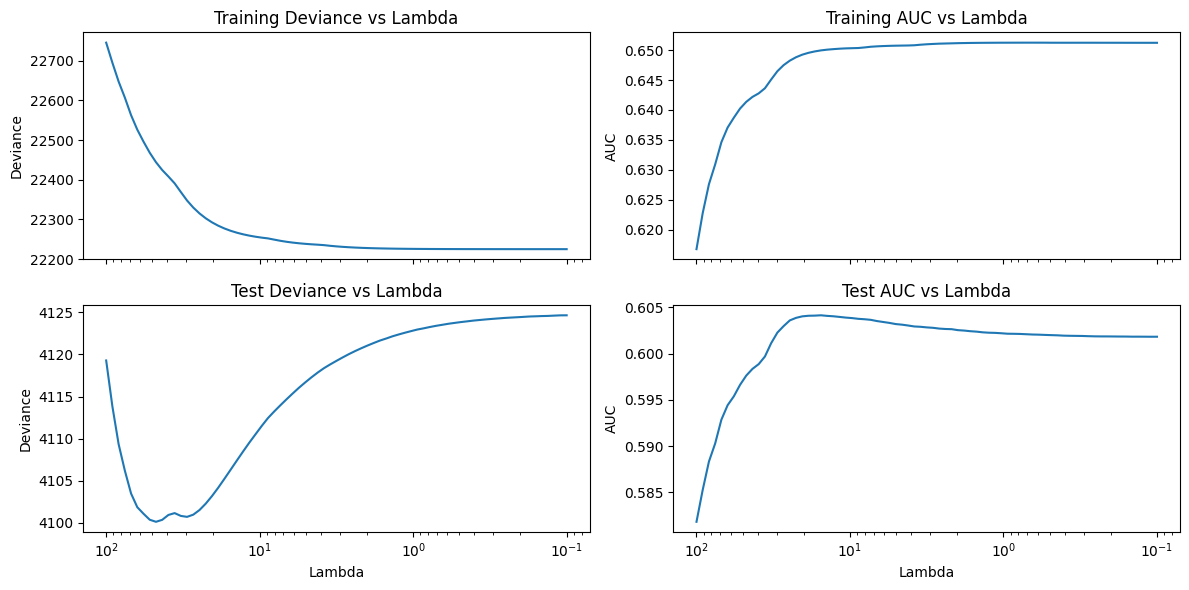

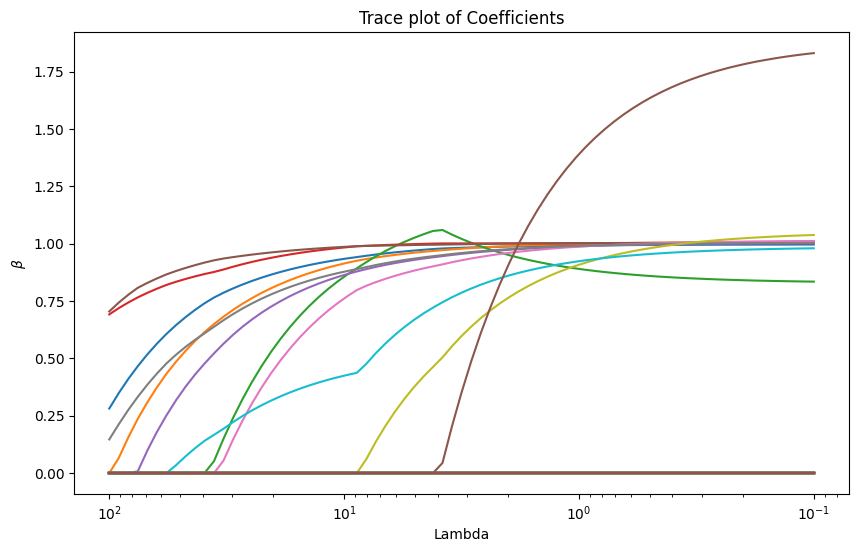

In [24]:
lambdas_prn, betas_prn, trainAUC_prn, testAUC_prn, trainDev_prn, testDev_prn, glmPred_prn = prLASSO(F_covariates_train_prn, F_covariates_test_prn,y_train, y_test, num_lambdas=75, log_max_lambda=2,log_min_lambda=-1,verbose=True)

In [25]:
# userLambda_prn = selectLambda(lambdas_prn, betas_prn, testAUC_prn, testDev_prn, x_train, bivariate_inputs)
userLambda_prn = 40
# userLambda_prn = 20
lambdas_prn[userLambda_prn]

2.389892566231049

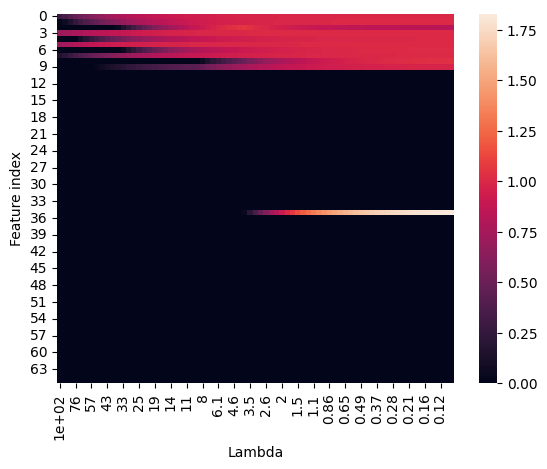

In [26]:
ax = sns.heatmap(betas_prn, xticklabels=lambdas_prn)
ax.set_xticklabels(["{:.2g}".format(x) for x in lambdas_prn], rotation=90)
ax.set_xlabel('Lambda')
ax.set_ylabel('Feature index')

# reduce number of xtick labels
ax.set_xticks(ax.get_xticks()[::3]);


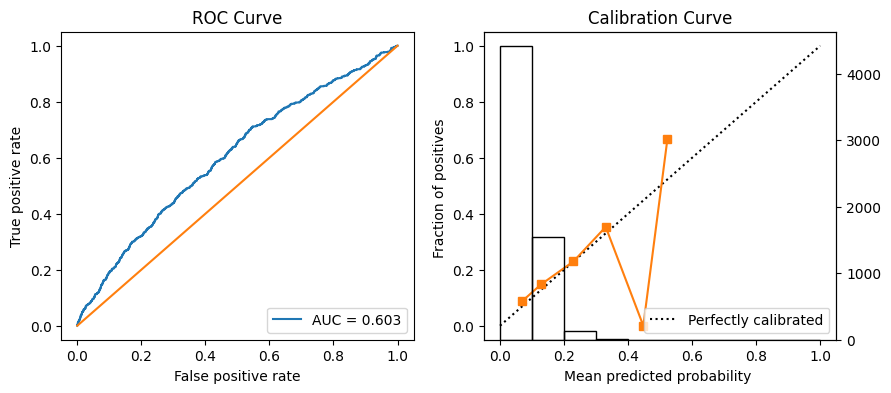


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.238
specificity: 0.867
accuracy: 0.8
ppv: 0.177
auc score: 0.603
auc lower ci: 0.581
auc upper ci: 0.627
-------------------------


{'prevalence': 0.123,
 'sensitivity': 0.238,
 'specificity': 0.867,
 'accuracy': 0.8,
 'ppv': 0.177,
 'auc score': 0.603,
 'auc lower ci': '0.581',
 'auc upper ci': '0.627'}

In [27]:
modelStats(glmPred_prn[:,userLambda_prn], y_test, y_train, auc_ci=True)

## Validation inference

Univariate Responses:
Column 0:
Column 1:
Column 2:
Column 3:
Column 4:
Column 5:
Column 6:
Column 7:
Column 8:
Column 9:
Column 10:
Bivariate Responses:
Columns 0 & 1:
Columns 0 & 2:
Columns 0 & 3:
Columns 0 & 4:
Columns 0 & 5:
Columns 0 & 6:
Columns 0 & 7:
Columns 0 & 8:
Columns 0 & 9:
Columns 0 & 10:
Columns 1 & 2:
Columns 1 & 3:
Columns 1 & 4:
Columns 1 & 5:
Columns 1 & 6:
Columns 1 & 7:
Columns 1 & 8:
Columns 1 & 9:
Columns 1 & 10:
Columns 2 & 3:
Columns 2 & 4:
Columns 2 & 5:
Columns 2 & 6:
Columns 2 & 7:
Columns 2 & 8:
Columns 2 & 9:
Columns 2 & 10:
Columns 3 & 4:
Columns 3 & 5:
Columns 3 & 6:
Columns 3 & 7:
Columns 3 & 8:
Columns 3 & 9:
Columns 3 & 10:
Columns 4 & 5:
Columns 4 & 6:
Columns 4 & 7:
Columns 4 & 8:
Columns 4 & 9:
Columns 4 & 10:
Columns 5 & 6:
Columns 5 & 7:
Columns 5 & 8:
Columns 5 & 9:
Columns 5 & 10:
Columns 6 & 7:
Columns 6 & 8:
Columns 6 & 9:
Columns 6 & 10:
Columns 7 & 8:
Columns 7 & 9:
Columns 7 & 10:
Columns 8 & 9:
Columns 8 & 10:
Columns 9 & 10:
Residual


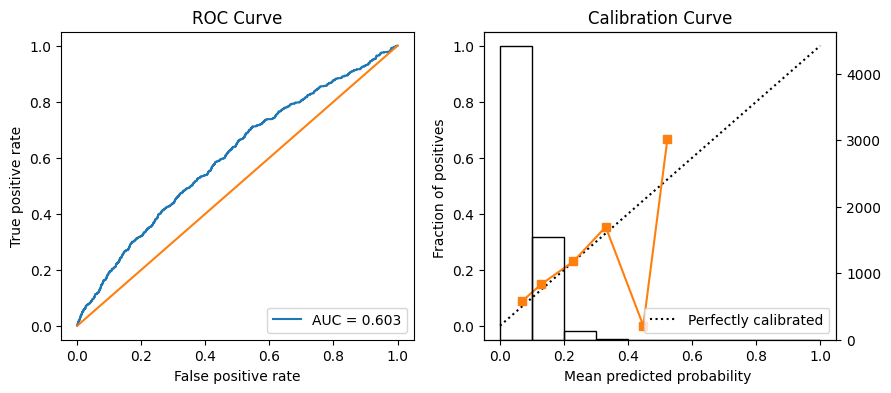


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.238
specificity: 0.867
accuracy: 0.8
ppv: 0.177
auc score: 0.603
auc lower ci: 0.575
auc upper ci: 0.63
-------------------------


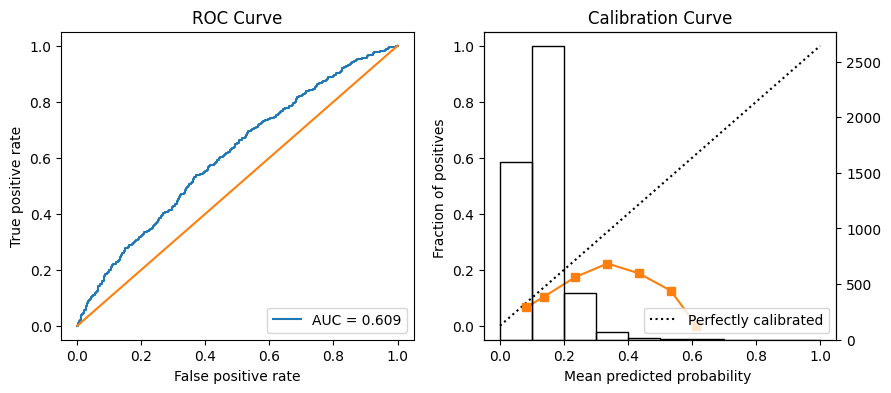


-------- Metrics --------
prevalence: 0.123
sensitivity: 0.594
specificity: 0.558
accuracy: 0.561
ppv: 0.129
auc score: 0.609
auc lower ci: 0.582
auc upper ci: 0.629
-------------------------


{'prevalence': 0.123,
 'sensitivity': 0.594,
 'specificity': 0.558,
 'accuracy': 0.561,
 'ppv': 0.129,
 'auc score': 0.609,
 'auc lower ci': '0.582',
 'auc upper ci': '0.629'}

In [28]:
F_covariates_train_prn, F_covariates_val_prn, bivariate_inputs_prn = partialResponses(x_train, x_val, prn_weights, residual=False, method = method,device=device);

lasso_params = {
    'C': 1/lambdas_prn[userLambda_prn],
    'penalty': 'l1',
    'solver': 'saga',
    'max_iter': 10000
}

prn_lasso = LogisticRegression(**lasso_params)
prn_lasso.fit(F_covariates_train_prn, y_train.to_numpy().ravel())

y_pred_test_prn_lasso = prn_lasso.predict_proba(F_covariates_test_prn)[:, 1]
y_pred_val_prn_lasso = prn_lasso.predict_proba(F_covariates_val_prn)[:, 1]
lasso_metrics_test = modelStats(y_pred_test_prn_lasso, y_test, y_train, auc_ci=True)
modelStats(y_pred_val_prn_lasso, y_val, y_train, auc_ci=True)


In [29]:
if SAVE_MODELS:
    save_lasso(prn_lasso, lasso_params, lasso_metrics_test, MODELS_DIR)

LASSO model saved as lasso_model_20240705_141214


## User selected Partial Response plots from the Partial Response Network

0 - univ


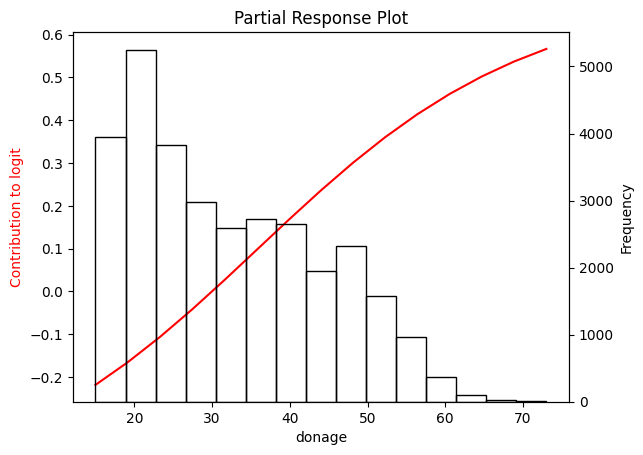

1 - univ


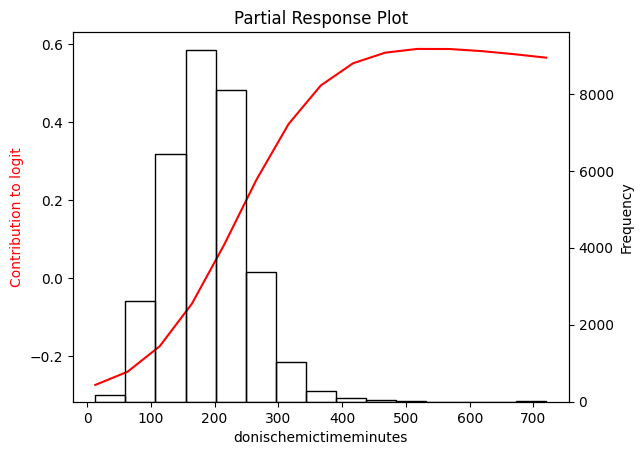

2 - univ


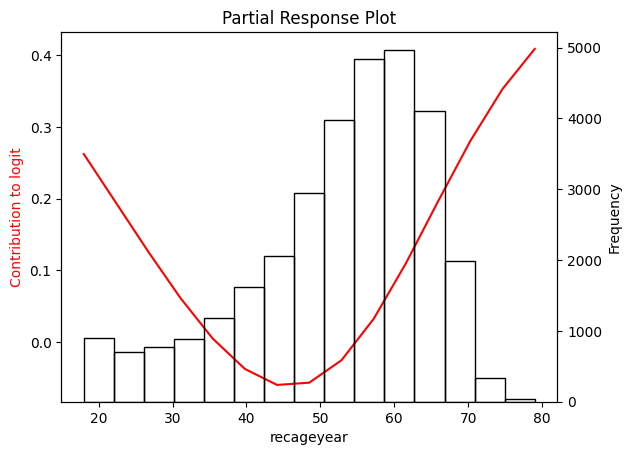

3 - univ


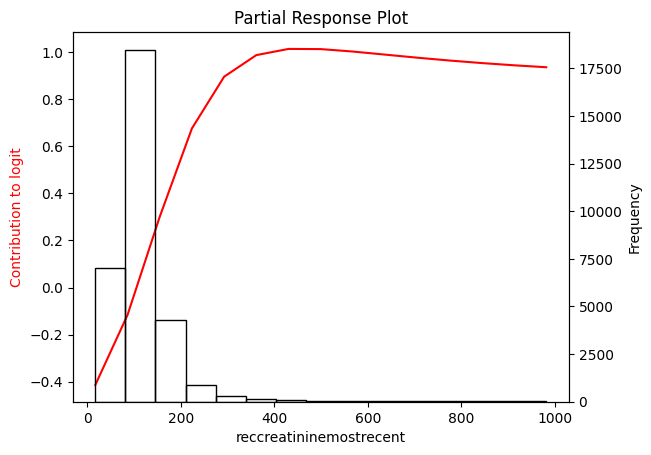

4 - univ


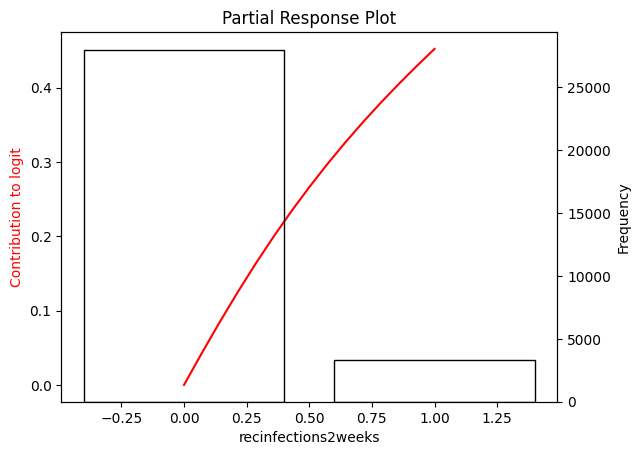

5 - univ


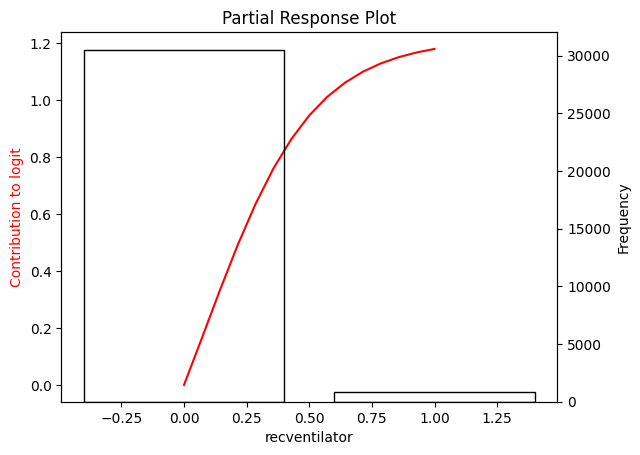

6 - univ


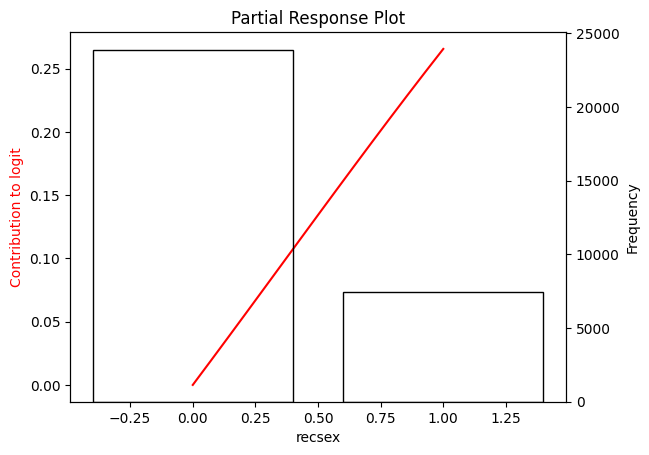

7 - univ


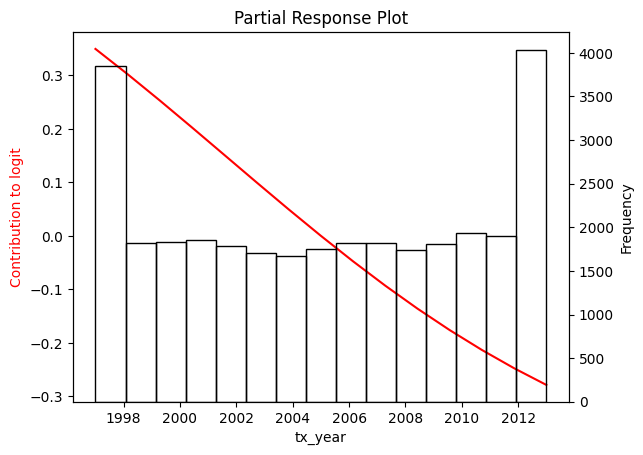

8 - univ


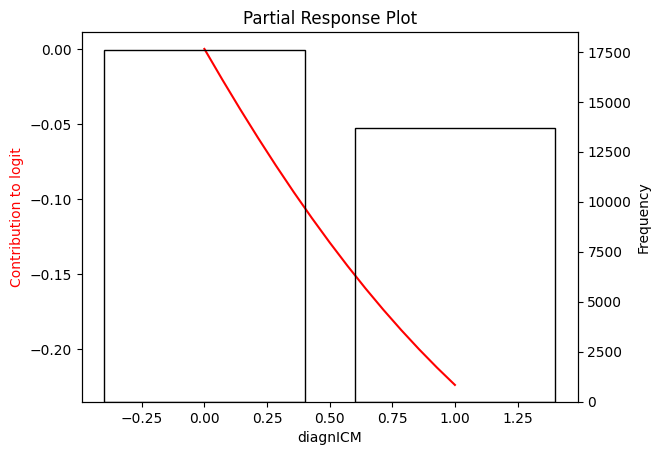

9 - univ


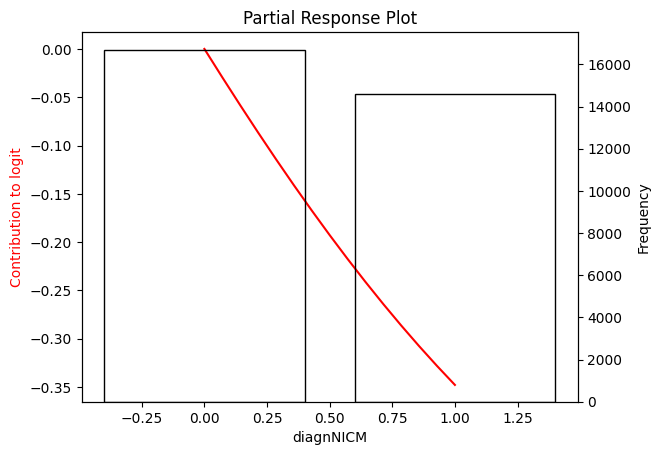

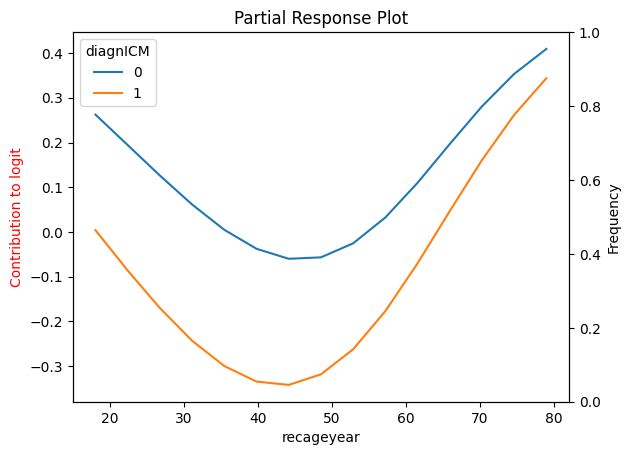

In [30]:
prPlots(betas_prn, userLambda_prn, x_train0, x_train, data_train_test, prn, bivariate_inputs_prn, n_steps = 15, sd_scale=2, method=method,device=device)

## Partial Response Network Nomogram

C:\Users\Henry Pigot\Documents\MEGAsync\2024 post doc\explainable survival prediction model\prism_github\prism\prnomogram.py:463: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  nomo.show()


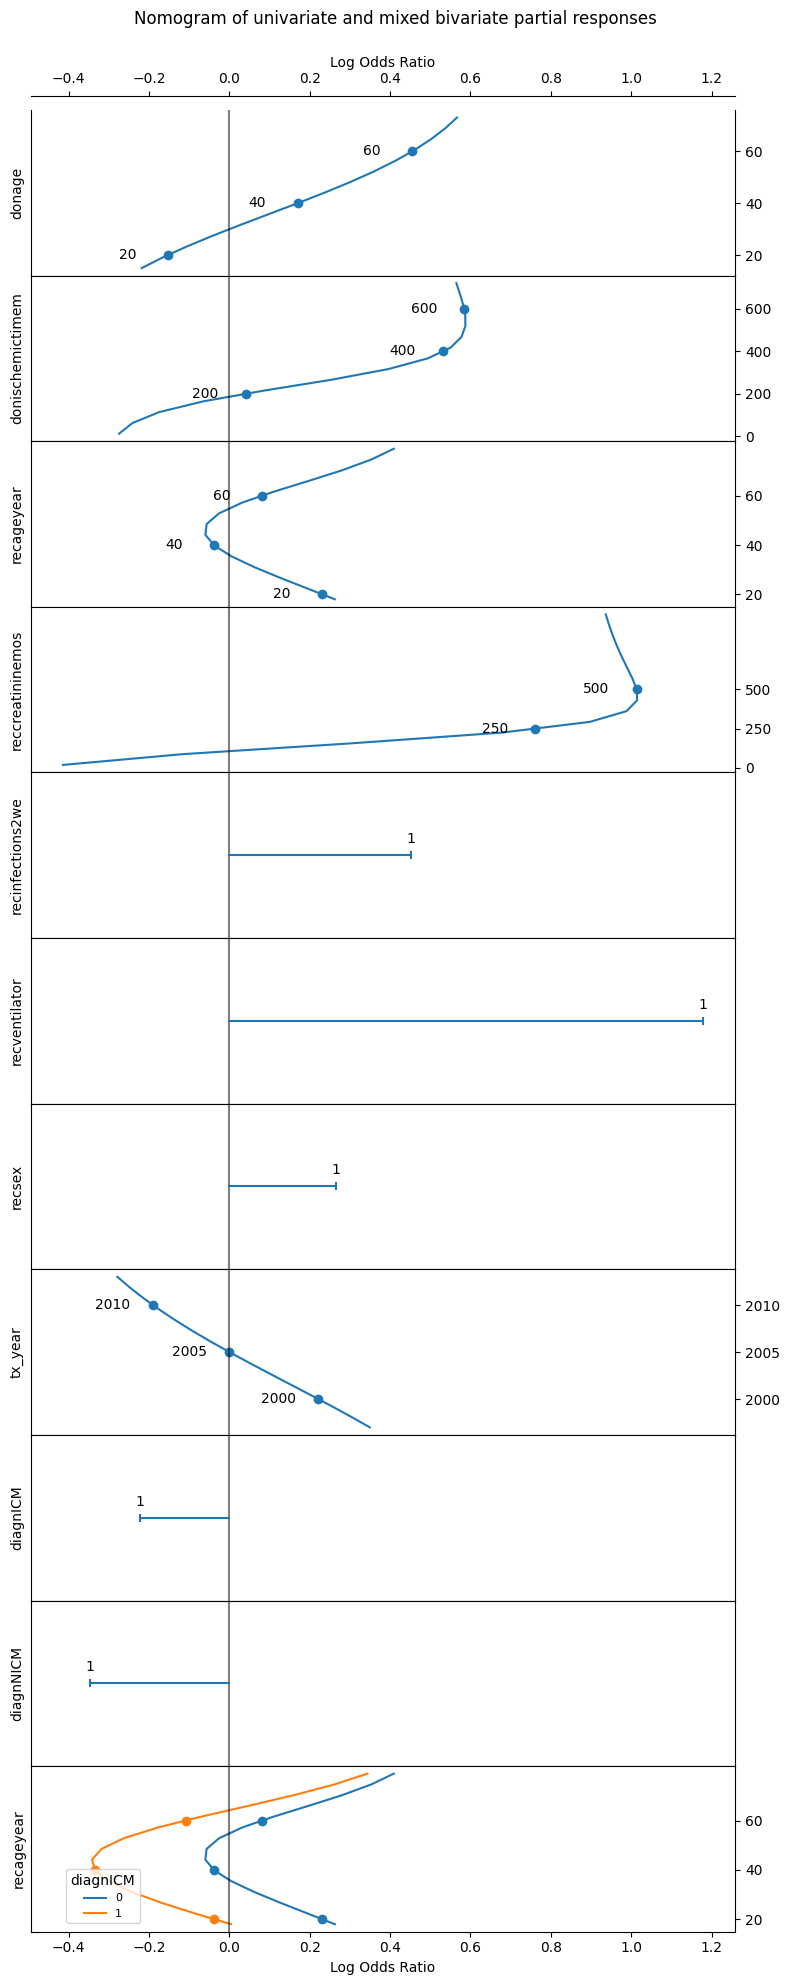

In [31]:
prnomogram_refactor(betas_prn, userLambda_prn, x_train0, x_train, data_train_test, prn_weights, bivariate_inputs_prn,device=device,method=method)